# 🔍 SHAP 模型解释深度笔记

> **核心理念**：基于博弈论，将模型预测值公平地分配到每个特征上。
> **公式理解**：最终预测值 = 基准值 (Base Value) + Σ 特征1的SHAP值 + ... + 特征N的SHAP值

---

### 1. 特征重要性图 (Bar Plot / Feature Importance)
*   **形式**：横向条形图。
*   **原理**：计算每个特征在所有样本上 SHAP 绝对值的平均值 `mean(|SHAP value|)`。
*   **解读**：
    - **长度**：代表该特征对模型输出的影响力。
    - **局限**：只显示影响力大小，不显示影响的方向（正向还是负向）。
*   **适用场景**：全局特征筛选，向非技术人员展示核心影响因素。

---

### 2. 蜂群图 (Beeswarm Plot) —— 【最常用】
*   **形式**：散点密集的行阵，每个点代表一个样本。
*   **解读（三要素）**：
    1. **横坐标 (X轴)**：点在 0 右侧表示正向贡献（提升预测），左侧表示负向贡献。
    2. **颜色**：红色代表该特征本身的数值高，蓝色代表数值低。
    3. **分布**：点的厚度代表样本在该 SHAP 值的聚集程度。
*   **典型结论**：若“收入”特征右侧全是红点，说明收入越高，预测结果越高。
*   **适用场景**：观察特征值高低如何影响预测的方向和强度。

---

### 3. 依赖图 (Dependence)(对一个特征进行分析)
*   **形式**：二维散点图。
*   **横轴**：特征本身的原始取值；**纵轴**：该特征对应的 SHAP 值。
*   **解读**：
    - **趋势线**：展示特征与输出之间的非线性关系（如：是否呈 U 型、S 型或阶梯型）。
    - **颜色（交互）**：系统会自动选出另一个交互最强的特征进行着色。
*   **适用场景**：寻找业务阈值（例如：年龄超过 45 岁后，患病风险是否陡增）。

---

### 4. 热力图 (Heatmap)
*   **形式**：横轴为样本（按预测值排序），纵轴为特征。
*   **解读**：
    - **颜色深浅**：红色表示正向影响，蓝色负向影响。(这个颜色是指shap值大小而不是特征的大小)
    - **顶部曲线**：显示模型预测值的波动。
*   **适用场景**：识别样本聚类。观察是否有一组样本是因为相同的特征组合而得到高分，帮助划分用户群体（Persona）。

---

### 5. 交互图 (Interaction Plot)
*   **形式**：蜂群图的变体，专门剥离出“纯交互效应”。
*   **原理**：计算特征 A 和特征 B 共同作用产生的影响，剔除两者各自独立的影响。
*   **解读**：
    - 即使特征 A 独立影响力小，但在特定特征 B 的配合下（交互值高），可能产生巨大影响。
*   **适用场景**：挖掘“1 + 1 > 2”的协同效应（例如：单独看“性别”没影响，但“男性+高压工作”会导致极高的压力评分）。


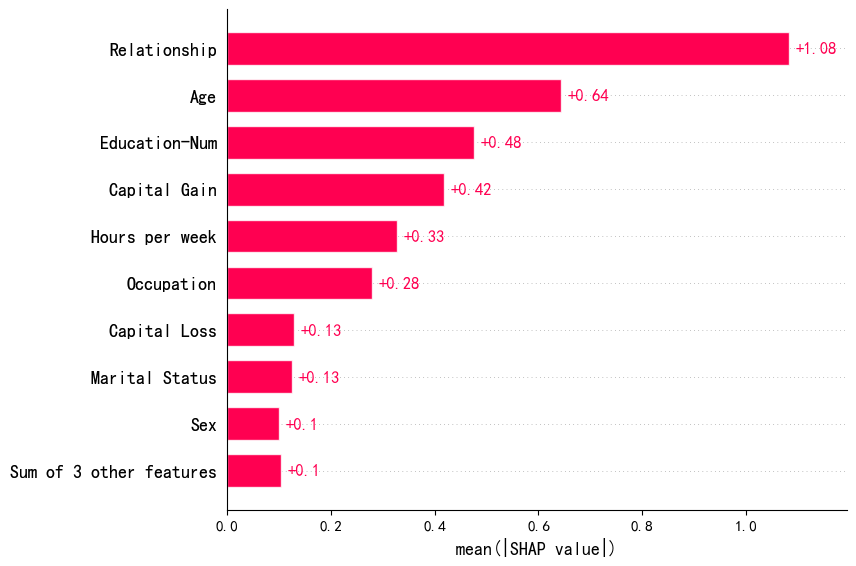

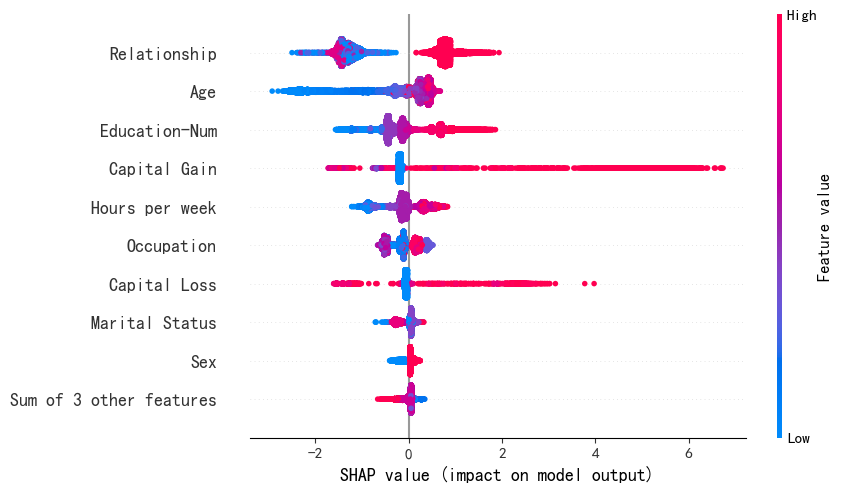

In [17]:
import xgboost as xgb
import shap
import pandas as pd
import matplotlib.pyplot as plt

# 1. 加载数据集 (SHAP 内置的 Adult 收入数据)
X, y = shap.datasets.adult()
# X 是特征, y 是标签 (是否收入 > 50k)

# 2. 训练 XGBoost 模型
# 注意：此数据集已处理过，数值化了，直接训练即可
model = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1)
model.fit(X, y)

# 3. 计算 SHAP 值
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

# 设置绘图字体（解决中文显示问题，如果没有中文可跳过）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# --- 开始绘图 ---

# 图 1：特征重要性条形图 (Bar Plot)
shap.plots.bar(shap_values, show=True)

# 图 2：蜂群图 (Beeswarm Plot)
shap.plots.beeswarm(shap_values, show=True) 

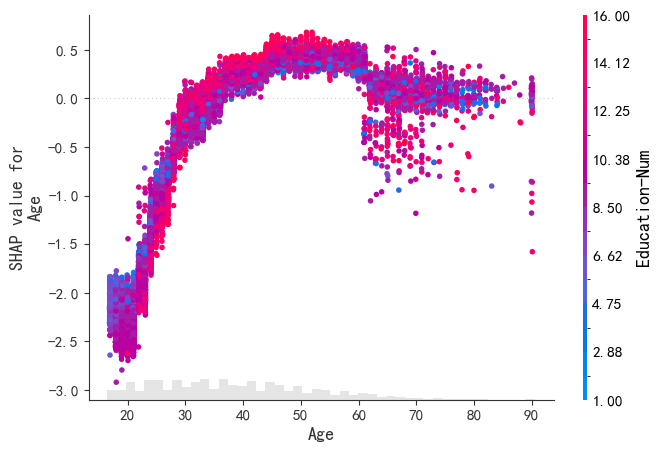

In [14]:
# 图 3：依赖图 (Scatter Plot) 
# color=shap_value自动找出与“年龄”交互作用最强的另一个特征来着色
shap.plots.scatter(shap_values[:, "Age"], color=shap_values, show=True)

# color用于解释同样的年龄（X 轴相同），对应的 SHAP 值却不一样(纵轴点是散开的)
# 因为模型考虑了特征交互

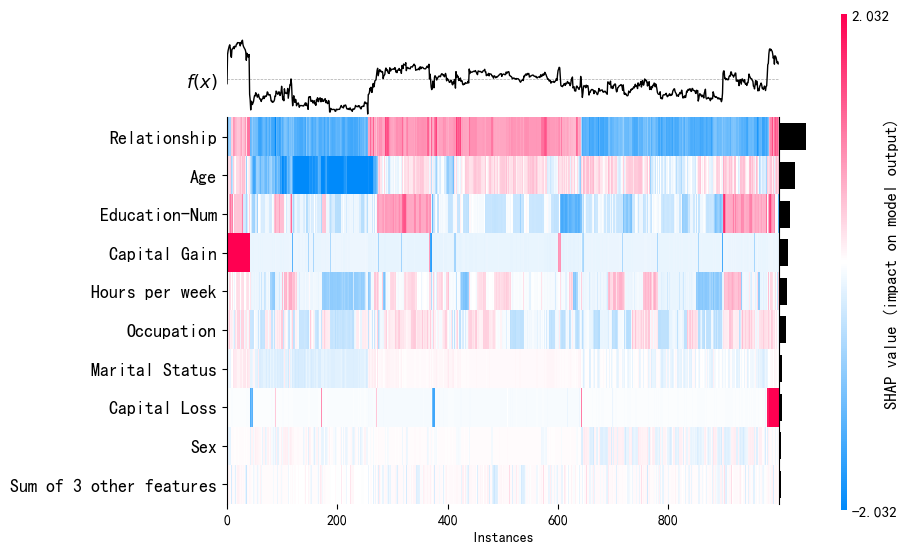

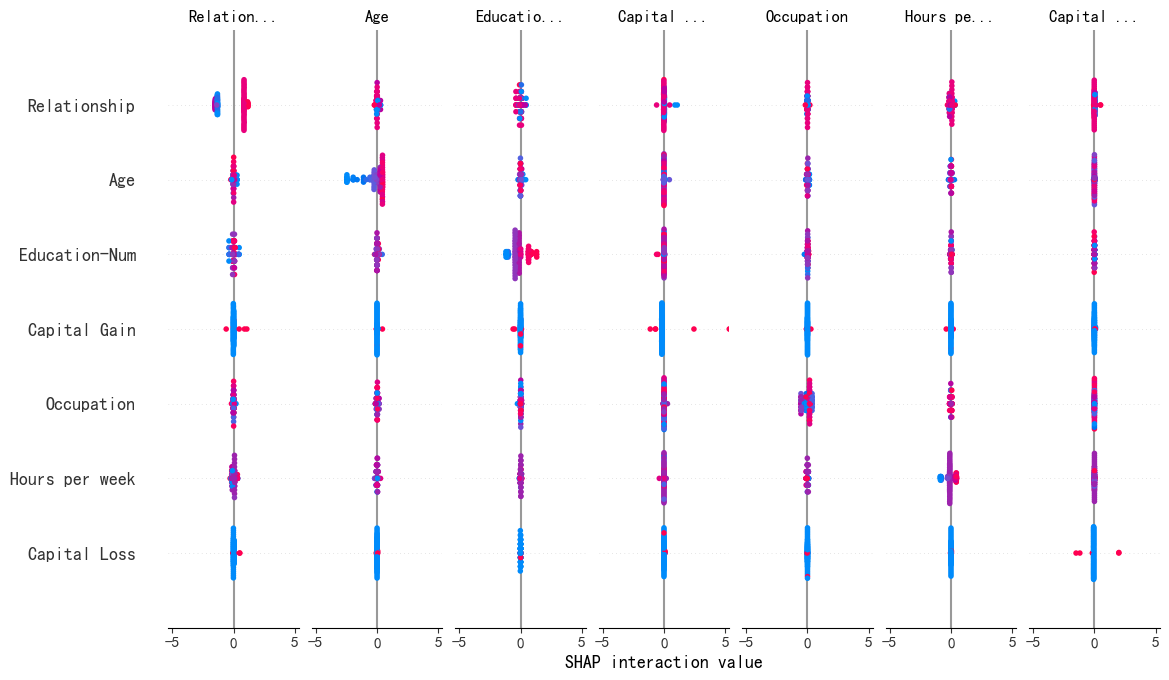

In [15]:
# 图 4：热力图 (Heatmap) - 展示前 1000 个样本的决策模式
shap.plots.heatmap(shap_values[:1000], show=True)

# 图 5：交互图 (Interaction Plot)
# 注意：交互值的计算非常耗时，这里只取前 100 个样本做演示
# 计算交互值（这一步在全量数据上非常慢，请慎用）
interact_values = explainer.shap_interaction_values(X.iloc[:100, :])
shap.summary_plot(interact_values, X.iloc[:100, :])

# 📍 SHAP 局部解释笔记：瀑布图 (Waterfall) & 力图 (Force)

> **核心目标**：拆解“黑盒”模型对【单个样本】的决策逻辑。
> **解释公式**：$f(x) = E[f(X)] + \sum SHAP_{i}$
> (最终预测 = 全局平均分 + 各特征贡献之和)

---

### 1. 瀑布图 (Waterfall Plot) —— "会计对账单"
*   **视觉逻辑**：从底部的“平均起跑线”开始，逐行加减，最终到达顶部的预测值。
*   **关键元素**：
    - **$E[f(X)]$ (起点)**：基准值 (Base Value)。模型对所有人的平均预测分。
    - **$f(x)$ (终点)**：该样本最终的预测分（对应 X 轴坐标）。
    - **红色条形**：正向贡献 (Positive SHAP)，把预测分往【高】推。
    - **蓝色条形**：负向贡献 (Negative SHAP)，把预测分往【低】拉。
*   **特点**：顺序清晰，最适合做个案审计（Audit）或详细报告。

---

### 2. 力图 (Force Plot) —— "力量拔河赛"
*   **视觉逻辑**：展示正向力量（红）与负向力量（蓝）的博弈，红蓝交汇处即为结果。
*   **关键元素**：
    - **中心分界线**：最终预测值 $f(x)$。
    - **条形宽度**：代表力量大小。越宽说明该特征对本次预测的影响越猛。
    - **Higher/Lower**：红色箭头向右推（增加分值），蓝色箭头向左拉（降低分值）。
*   **特点**：极其紧凑，适合集成在 Web UI 界面中实时展示。

---

### 3. 数值深度理解：X 轴到底是什么？
*   **坐标空间**：对于分类模型，数值通常是 **Log-Odds (Logit)**。
    - `0` 对应概率 `50%`。
    - `负数` 对应概率 `< 50%`。
    - `正数` 对应概率 `> 50%`。
*   **非线性逻辑**：特征贡献是【相对】的。
    - *例子*：Capital Gain = 2174 显示为蓝色（减分），是因为相对于“高收入精英”的平均水平，这个数太小了，模型认为这反而降低了他是富人的可能性。



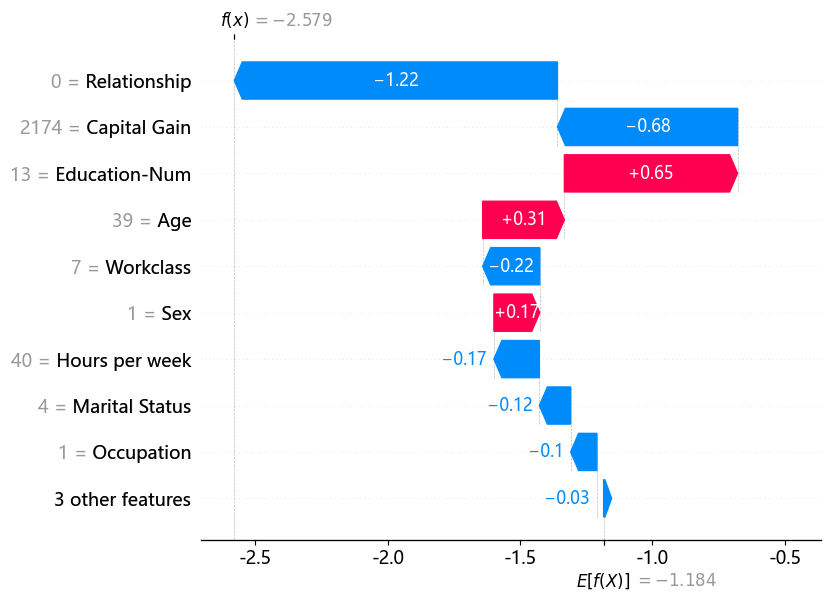

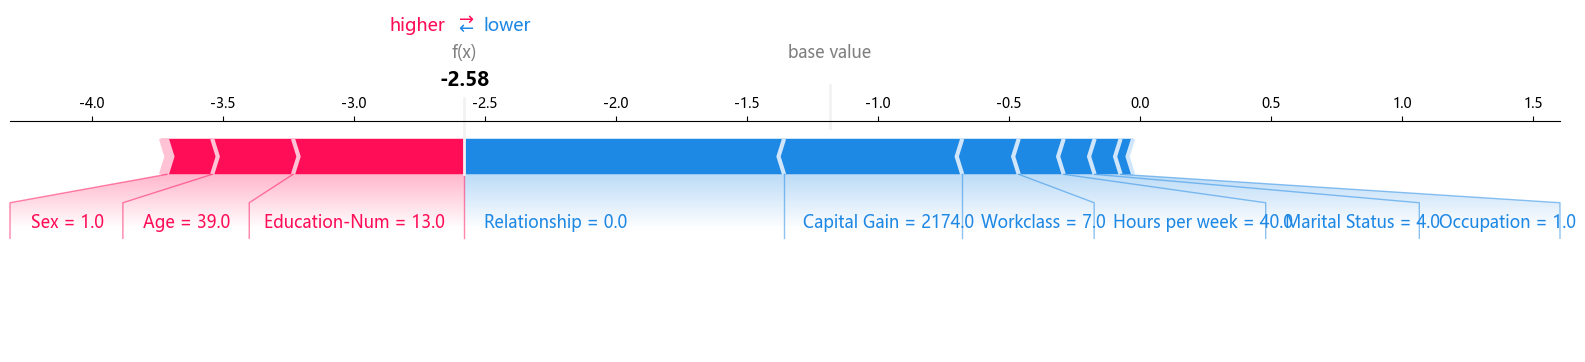

In [24]:
import matplotlib.pyplot as plt

# 解决负号 '-' 显示为方块的问题
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False 

# --- 1. 绘制第一个样本的瀑布图 ---
# 这里的 [0] 代表第一个样本
shap.plots.waterfall(shap_values[0])

# --- 2. 绘制第一个样本的力图 ---
# 注意：在 Jupyter Notebook 中需要先运行 initjs()
shap.initjs()
# shap_values.base_values[0] 是基准值
# shap_values.values[0] 是该样本各特征的 SHAP 值
shap.plots.force(shap_values[0], matplotlib=True)